### imports & direcories

In [1]:
import numpy as np
import pandas as pd
import itertools
from pathlib import Path
from joblib import Parallel, delayed

from models.A_exc_B_inh_A import A_exc_B_inh_A
from models.qmlif import QMLIFNeuron
from models.synapse import Synapse
from models.current import sinusoidal_current
from analysis.metrics import spike_times, spike_frequency
from analysis import plot

ROOT = Path.cwd().parent
FIG_DIR = ROOT / "fig/parameter_space_exploration"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ROOT / "results/parameter_space_exploration"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# $w_\mathrm{inh}$ analysis

In [ ]:
T = 10

w_inh_values = np.linspace(0, 4, 100)
last_spk_time = []  # time of last spike of A

for w_inh in w_inh_values:
    neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
    neuronB = QMLIFNeuron(name="neuronB")

    synapse_exc = Synapse(w=0.05, tau_syn=0.05)
    synapse_inh = Synapse(w=w_inh, tau_syn=0.07)

    input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

    network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

    simulation_data = network.simulate(T, input_current)

    spikes = spike_times(simulation_data["spkA"])
    last_spk = spikes[-1] if len(spikes) > 0 else 0
    last_spk_time.append(last_spk)

df = pd.DataFrame({"w_inh": w_inh_values, "last_spk_time": last_spk_time})
df.to_csv(RESULTS_DIR / "last_spk_vs_w_inh_07.csv", index=False)

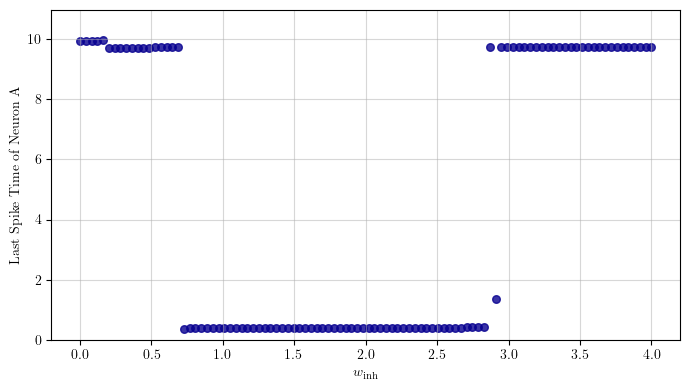

In [2]:
df = pd.read_csv(RESULTS_DIR / "last_spk_vs_w_inh_07.csv")
fig = plot.last_spike_vs_w_inh(df)
fig.savefig(FIG_DIR / "last_spk_vs_w_inh_07.pdf", bbox_inches="tight")

In [ ]:
T = 10

w_inh_values = np.linspace(0, 4, 100)
last_spk_time = []  # time of last spike of A

for w_inh in w_inh_values:
    neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
    neuronB = QMLIFNeuron(name="neuronB")

    synapse_exc = Synapse(w=0.05, tau_syn=0.05)
    synapse_inh = Synapse(w=w_inh, tau_syn=0.1)     # increased inhibitory time constant

    input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

    network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

    simulation_data = network.simulate(T, input_current)
    
    spikes = spike_times(simulation_data["spkA"])
    last_spk = spikes[-1] if len(spikes) > 0 else 0
    last_spk_time.append(last_spk)

df = pd.DataFrame({"w_inh": w_inh_values, "fr": fr, "last_spk_time": last_spk_time})
df.to_csv(RESULTS_DIR / "fr_vs_w_inh_tau_inh_01.csv", index=False)

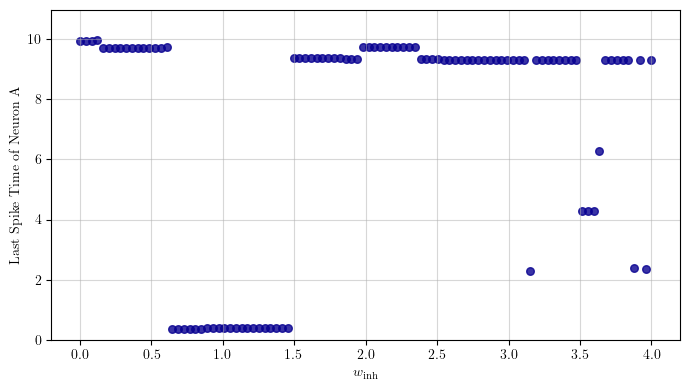

In [3]:
df = pd.read_csv(RESULTS_DIR / "fr_vs_w_inh_tau_inh_01.csv")
fig = plot.last_spike_vs_w_inh(df)
fig.savefig(FIG_DIR / "last_spk_vs_w_inh_01.pdf", bbox_inches="tight")

# $w_\mathrm{inh}$ and $\tau_\mathrm{inh}$ analysis

In [10]:
T = 10

def run_w_tau_analysis(w, tau):

    neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
    neuronB = QMLIFNeuron(name="neuronB")

    synapse_exc = Synapse(w=0.05, tau_syn=0.05)
    synapse_inh = Synapse(w=w, tau_syn=tau)

    input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

    network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

    simulation_data = network.simulate(T, input_current)

    spikes = spike_times(simulation_data["spkA"])
    last_spk = spikes[-1] if len(spikes) > 0 else 0

    return {
        "w": w,
        "tau": tau,
        "last_spk_time": last_spk,
    }

In [11]:
# parallel results for faster execution
# 20 I₀ values × 20 f values = 400 simultions
# 10s per simulation -> >66h

w_values = np.linspace(0.1, 1.0, 20)
tau_values = np.linspace(0.01, 0.1, 20)

results = Parallel(
    n_jobs=-1,
    prefer="processes",
    verbose=10
)(
    delayed(run_w_tau_analysis)(w, tau)
    for w, tau in itertools.product(w_values, tau_values)
)

df = pd.DataFrame(results)
df.to_csv(RESULTS_DIR/"w_vs_tau.csv", index=False)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   24.5s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   44.8s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done  78 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done 125 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 161 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed: 1

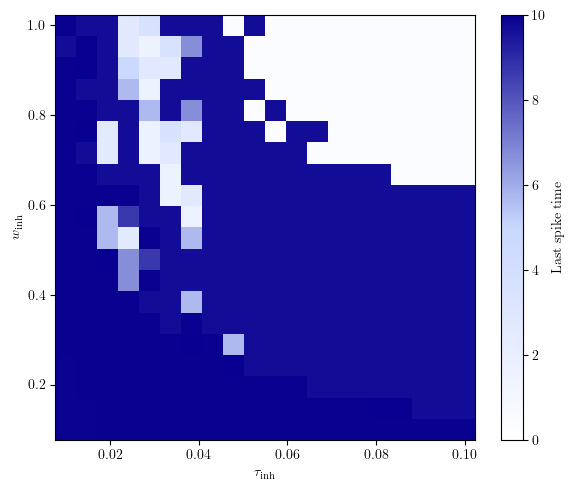

In [9]:
T=10
df=pd.read_csv(RESULTS_DIR/"w_vs_tau.csv")
fig = plot.silence_heatmap(df, index="w", columns="tau", T=T, xlabel=r"$\tau_\mathrm{inh}$", ylabel=r"$w_\mathrm{inh}$")
fig.savefig(FIG_DIR / "w_vs_tau.pdf", bbox_inches="tight")

# $I_0$ and $f_\mathrm{drive}$ analysis

In [13]:
T = 10

def run_I0_f_analysis(I0, f):

    neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
    neuronB = QMLIFNeuron(name="neuronB")

    synapse_exc = Synapse(w=0.05, tau_syn=0.05)
    synapse_inh = Synapse(w=0.7, tau_syn=0.07)

    input_current = sinusoidal_current(T, T, I0, f)

    network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

    simulation_data = network.simulate(T, input_current)

    spikes = spike_times(simulation_data["spkA"])
    last_spk = spikes[-1] if len(spikes) > 0 else 0

    return {
        "I0": I0,
        "f": f,
        "last_spk_time": last_spk
    }

In [14]:
# parallel results for faster execution
# 20 I₀ values × 20 f values = 400 simultions
# 10s per simulation -> >66h

I0_values = np.linspace(0.1, 1.0, 20)
f_values = np.linspace(1.0, 10.0, 20)

results = Parallel(
    n_jobs=-1,
    prefer="processes",
    verbose=10
)(
    delayed(run_I0_f_analysis)(I0, f)
    for I0, f in itertools.product(I0_values, f_values)
)

df = pd.DataFrame(results)
df.to_csv(RESULTS_DIR/"I0_vs_f.csv", index=False)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   18.7s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   36.5s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   55.2s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   56.5s
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed: 18.7min
[Parallel(n_jobs=-1)]: Done  78 tasks      | elapsed: 19.0min
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed: 19.6min
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed: 20.0min
[Parallel(n_jobs=-1)]: Done 125 tasks      | elapsed: 20.6min
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed: 21.3min
[Parallel(n_jobs=-1)]: Done 161 tasks      | elapsed: 21.9min
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed: 22.4min
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed: 2

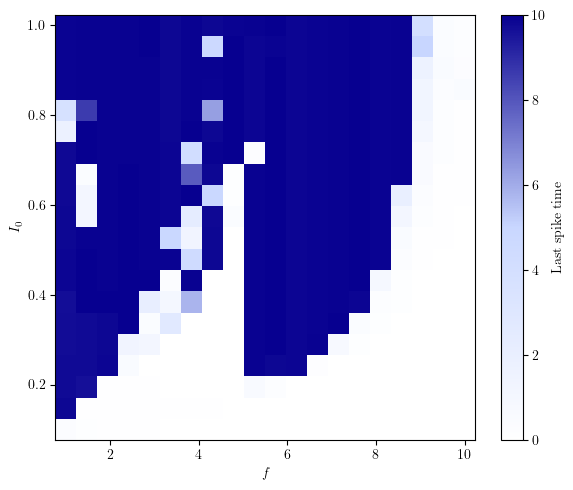

In [8]:
T=10
df=pd.read_csv(RESULTS_DIR/"I0_vs_f.csv")
fig = plot.silence_heatmap(df, index="I0", columns="f", T=T, xlabel=r"$f$", ylabel=r"$I_0$")
fig.savefig(FIG_DIR / "I0_vs_f.pdf", bbox_inches="tight")

# Heatmaps side by side

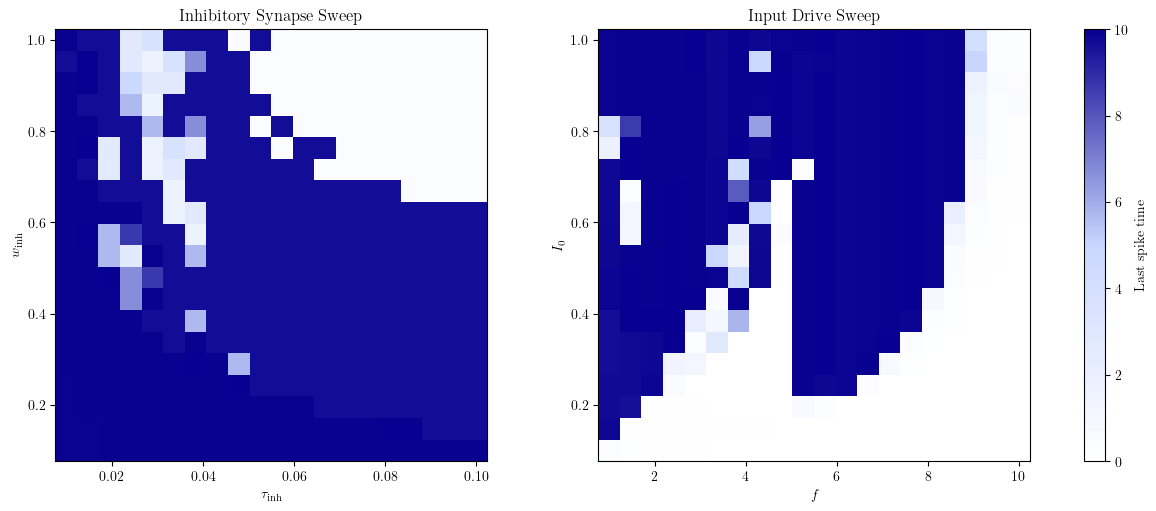

In [7]:
T=10
df1=pd.read_csv(RESULTS_DIR/"w_vs_tau.csv")
df2=pd.read_csv(RESULTS_DIR/"I0_vs_f.csv")

fig = plot.silence_heatmap_side_by_side(df1, df2, index1="w", columns1="tau", index2="I0", columns2="f", T=T,
                                        xlabel1=r"$\tau_\mathrm{inh}$", ylabel1=r"$w_\mathrm{inh}$", title1="Inhibitory Synapse Sweep",
                                        xlabel2=r"$f$", ylabel2=r"$I_0$", title2="Input Drive Sweep")
fig.savefig(FIG_DIR / "silent_heatmaps.pdf", bbox_inches="tight")

# Neurorn's behaviour investigation

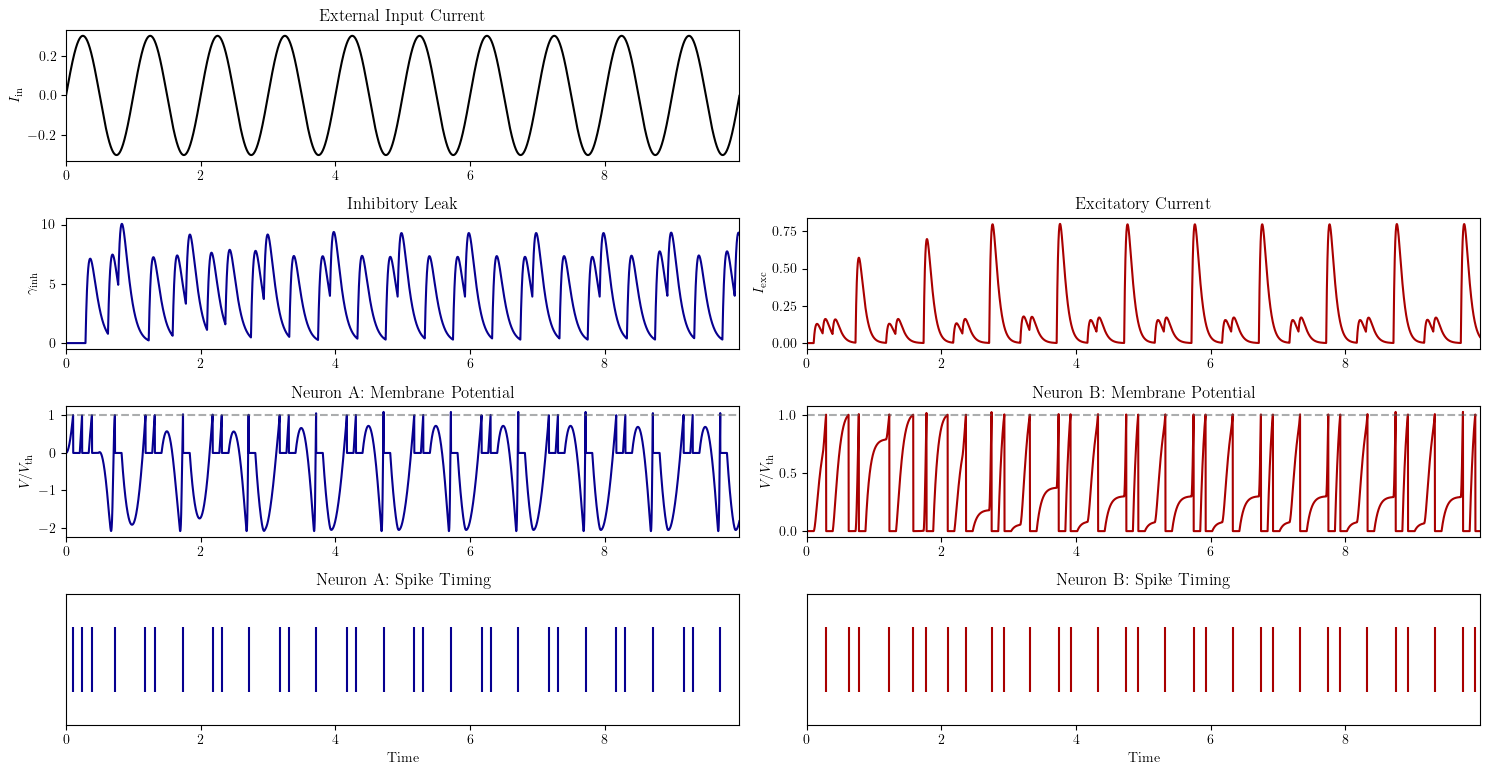

In [10]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.05, tau_syn=0.05)
synapse_inh = Synapse(w=0.69, tau_syn=0.07)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)

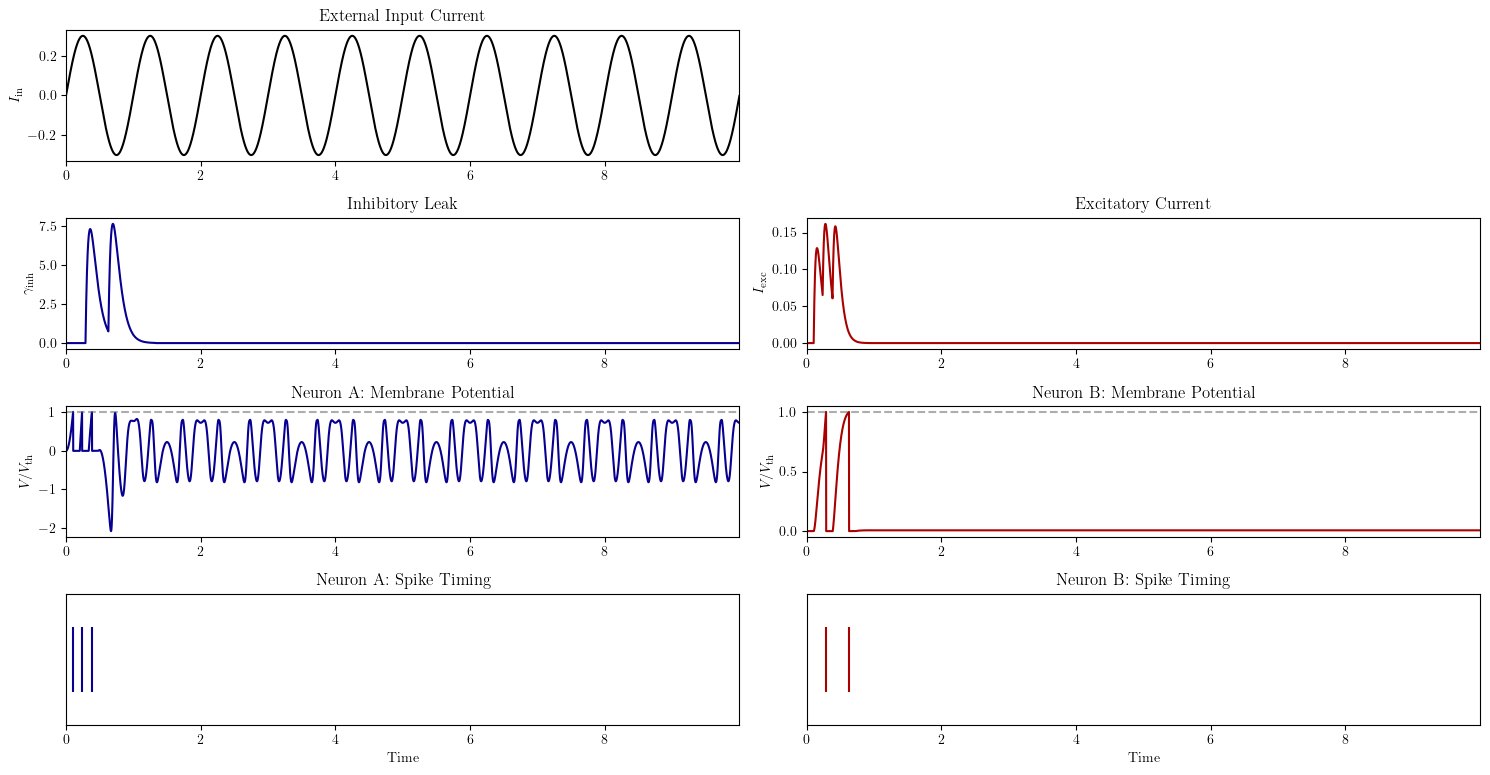

In [11]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.05, tau_syn=0.05)
synapse_inh = Synapse(w=0.71, tau_syn=0.07)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)

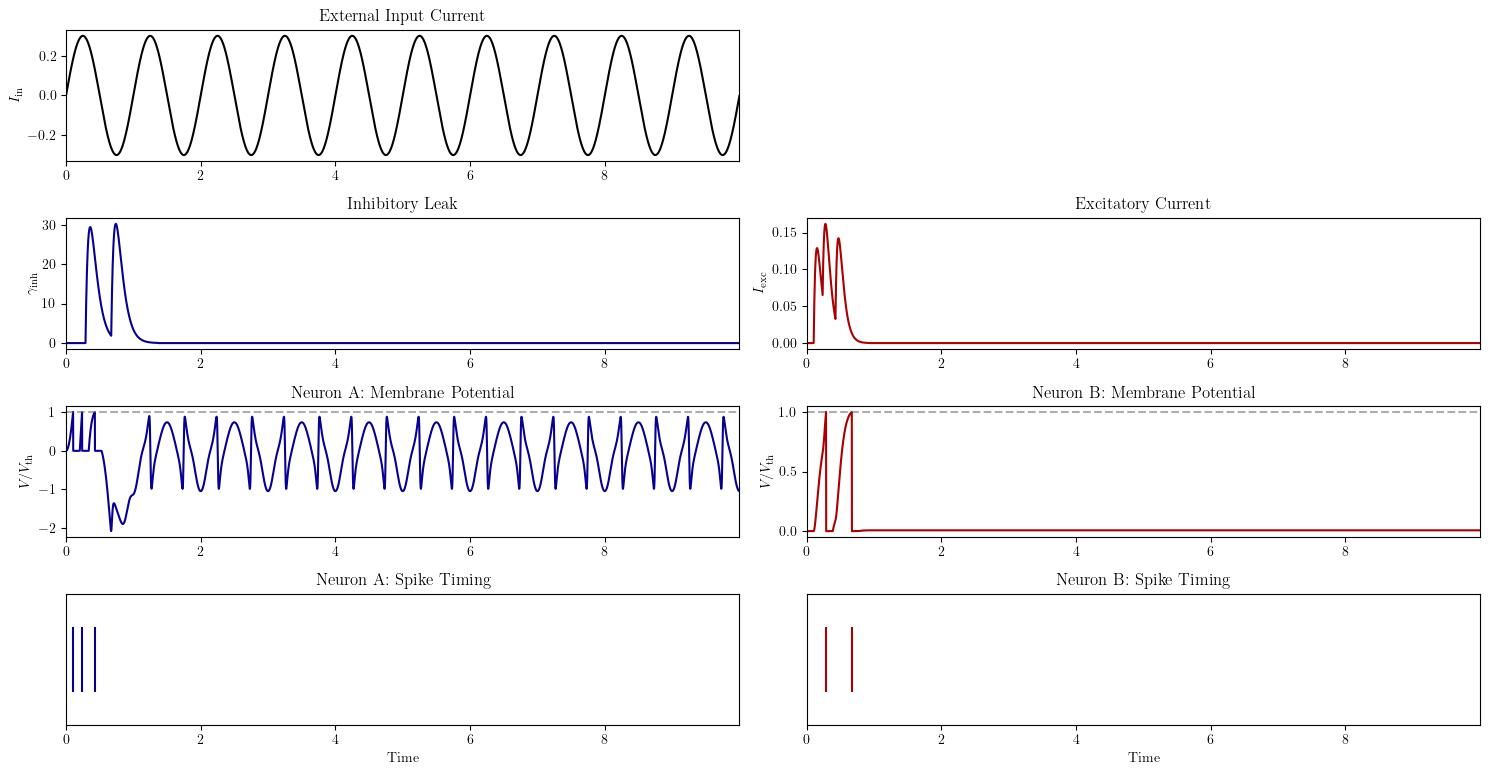

In [12]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.05, tau_syn=0.05)
synapse_inh = Synapse(w=2.85, tau_syn=0.07)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)

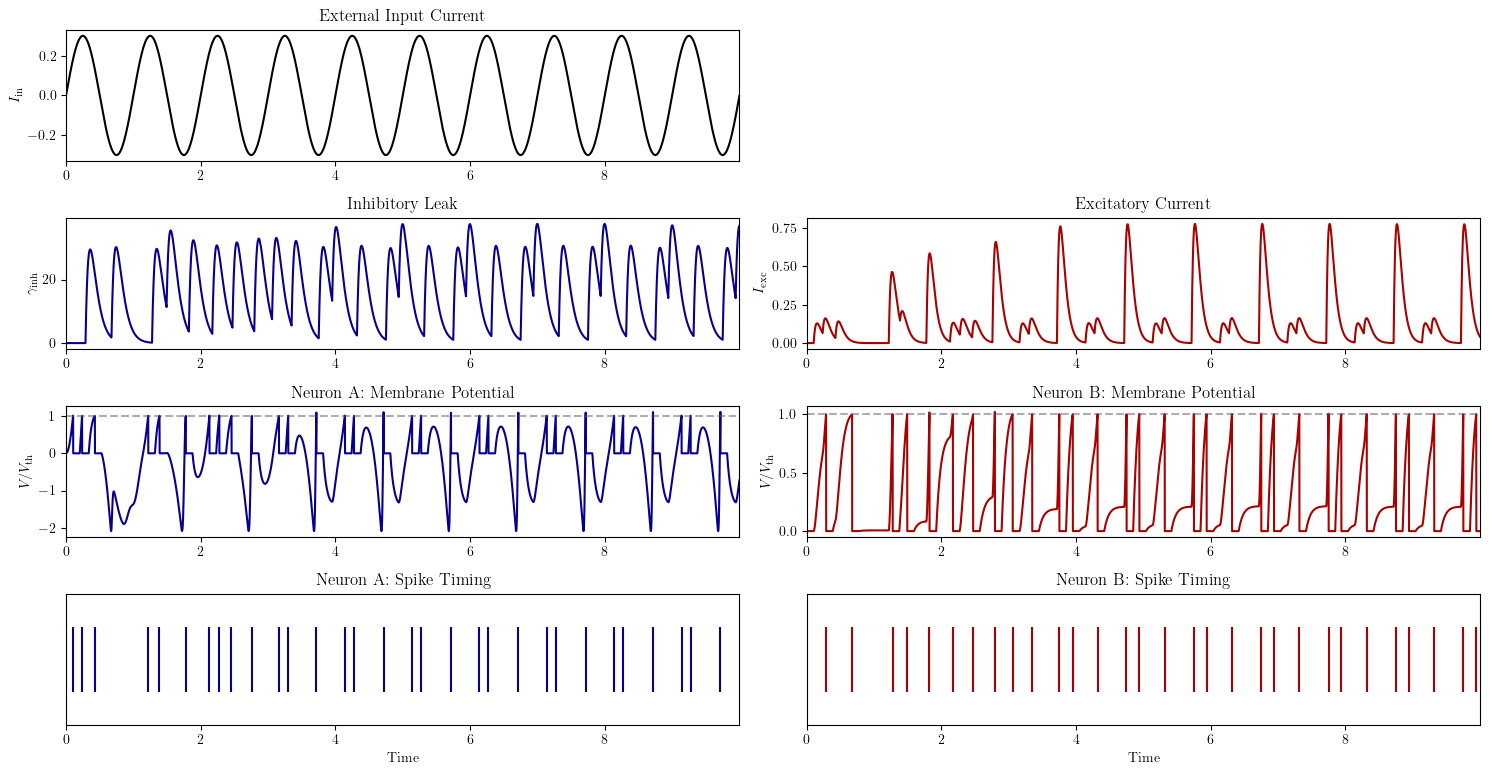

In [13]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.05, tau_syn=0.05)
synapse_inh = Synapse(w=2.86, tau_syn=0.07)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)

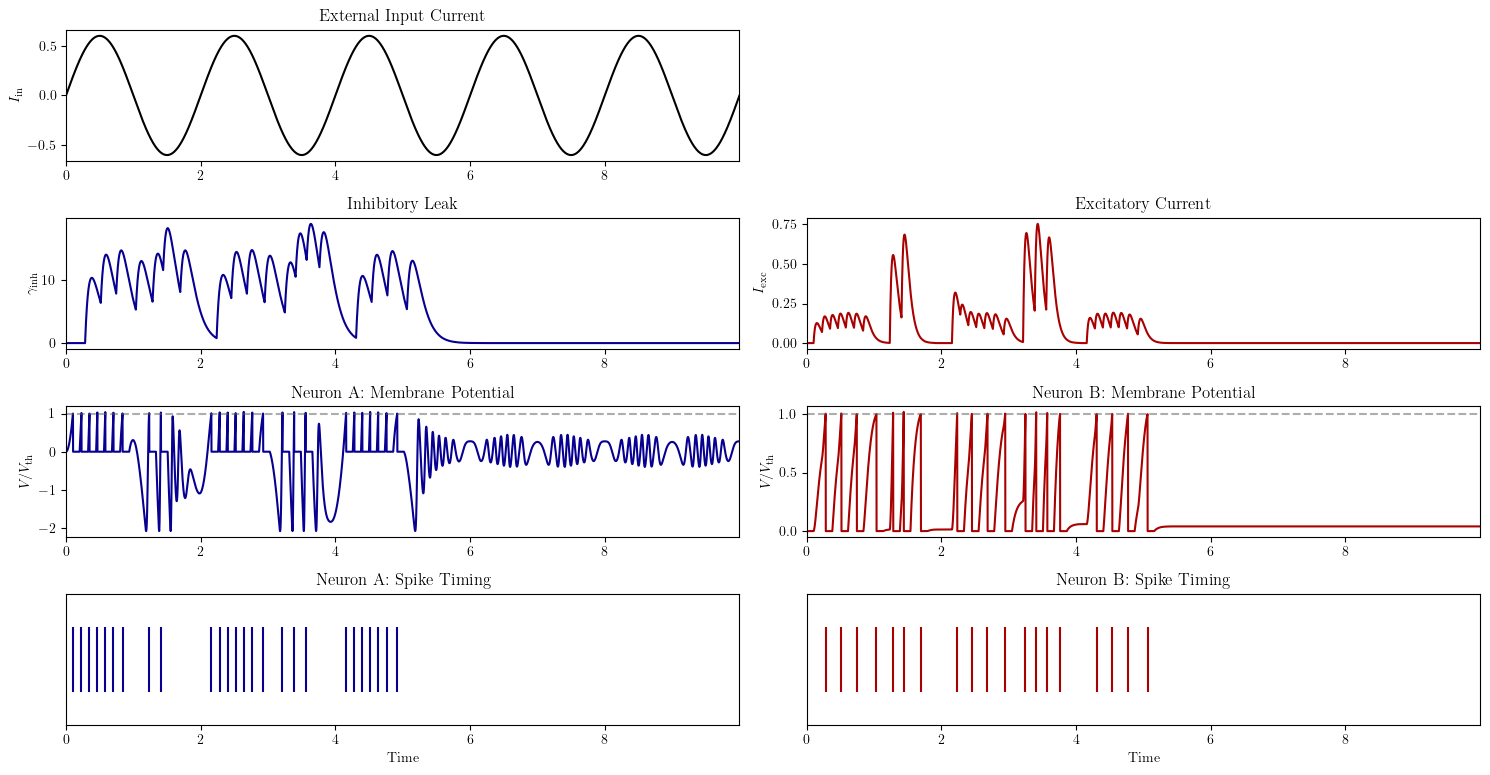

In [14]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

syn_exc = Synapse(w=0.05, tau_syn=0.05)
syn_inh = Synapse(w=1, tau_syn=0.1)

network = A_exc_B_inh_A(neuronA, neuronB, syn_exc, syn_inh)

current = sinusoidal_current(T=T, T_in=T, I0=0.6, f=0.5)

simulation_data = network.simulate(T, current)

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "parameter_space_exploration_example.pdf", bbox_inches="tight")

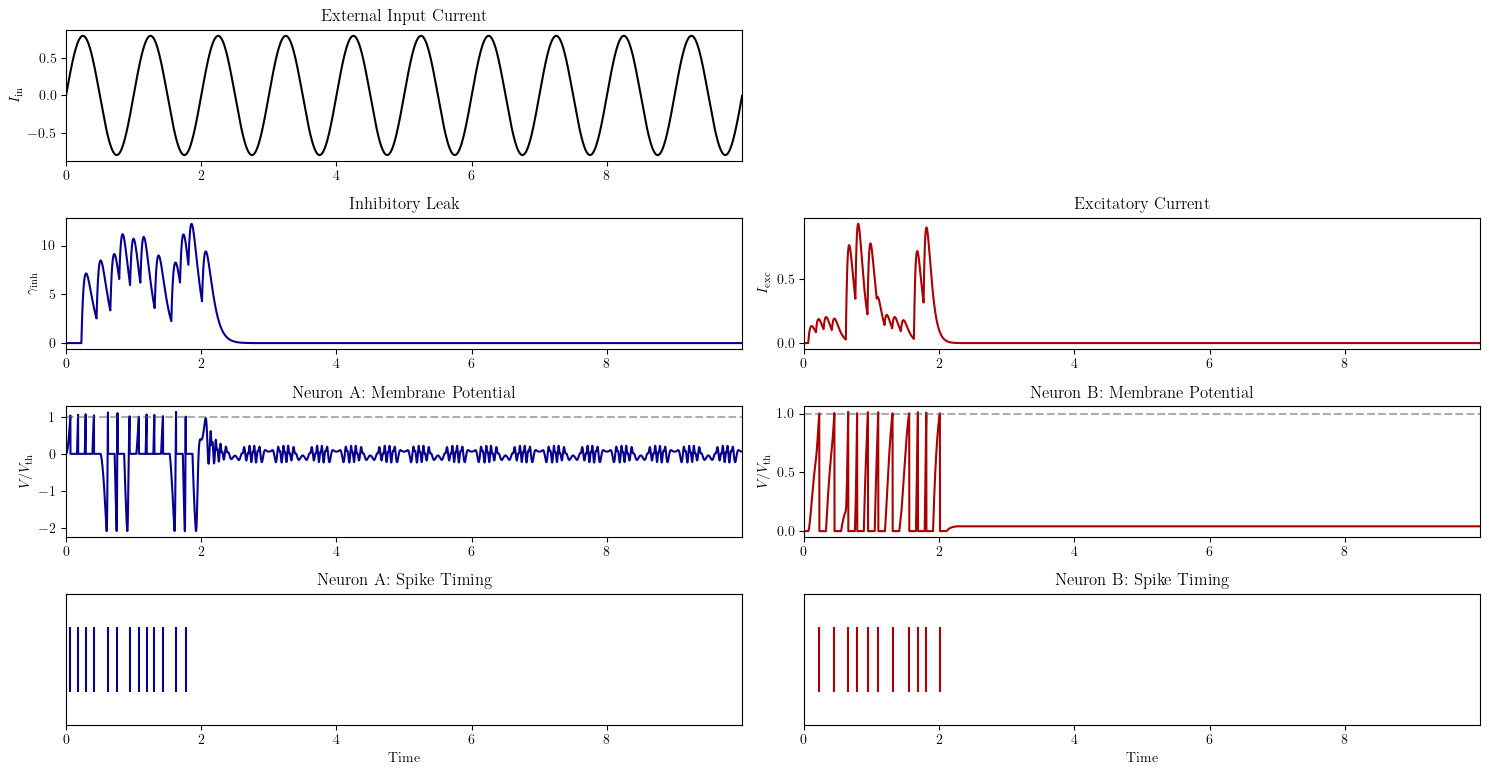

In [15]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.05, tau_syn=0.05)
synapse_inh = Synapse(w=0.69, tau_syn=0.07)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.8, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)